# Análisis de absentismo y bienestar laboral - 01/06/2026

## 1. Pregunta de negocio

> ¿Qué variables personales y laborales están asociadas con absentismo elevado y cómo ajustar políticas internas para reducir las ausencias?

## 2. Punto de partida: conexión con `analisis_perfil`

El notebook `Analisis_perfil_25052026.ipynb` ya revisó variables personales y laborales como edad, educación, hijos, distancia al trabajo, antigüedad, IMC, hábitos sociales, carga media y `Hit_target`.

Ese análisis mostró que el absentismo no se explica bien mediante relaciones lineales simples con variables individuales. Por eso, aquí no retrabajamos el análisis de perfil: lo usamos como base para ampliar la lectura desde absentismo y bienestar.

La lógica será:

1. revisar asociaciones personales/laborales sin afirmar causalidad;
2. si no hay una variable individual fuerte, pasar a impacto operativo;
3. proponer políticas internas basadas en motivos, momentos, concentración y segmentos agregados.


## 3. Dataset limpio utilizado y alcance mínimo


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')

COLOR_PRINCIPAL = 'teal'
COLOR_SECUNDARIO = 'steelblue'
COLOR_ALERTA = 'indianred'

DATA_FILE = '../../Data/clean/clean_data_01062026.csv'
df_RRHH = pd.read_csv(DATA_FILE)


In [2]:
alcance = pd.DataFrame({
    'métrica': [
        'registros limpios',
        'IDs observados',
        'horas totales de absentismo',
        'registros con ausencia > 0 horas'
    ],
    'valor': [
        len(df_RRHH),
        df_RRHH['ID'].nunique(),
        df_RRHH['Absenteeism_hours'].sum(),
        (df_RRHH['Absenteeism_hours'] > 0).sum()
    ]
})

alcance


,métrica,valor
0,registros limpios,844
1,IDs observados,136
2,horas totales de absentismo,6226
3,registros con ausencia > 0 horas,801


**Lectura:** el análisis trabaja con el clean consolidado del 01/06/2026. Las métricas describen la muestra disponible, no la plantilla completa de RapidExpress.


## 4. Variables personales y laborales consideradas

**Variables personales:** `Age`, `Education_name`, `Son`, `Pet`, `Social_drinker`, `Social_smoker`, `BMI_calculated`.

**Variables laborales:** `Service_time`, `Distance_Residence_Work`, `Transportation_expense`, `Work_load_Average_day`, `Hit_target`, `Disciplinary_failure`.

**Variables operativas:** `Reason_absence_name`, `Month_absence_name`, `Day_week_name`, `Seasons_name`.


## 5. Construcción de absentismo elevado

Para comparar segmentos usamos una vista agregada por `ID`. Definimos `absentismo_elevado` como IDs en el cuartil superior de horas acumuladas.

Este criterio no es un modelo predictivo ni una etiqueta individual. Es una regla exploratoria para comparar grupos de forma transparente.


In [23]:
df_empleados = df_RRHH.groupby('ID', as_index=False).agg(
    registros=('ID', 'size'),
    horas_totales=('Absenteeism_hours', 'sum'),
    media_horas=('Absenteeism_hours', 'mean'),
    Age=('Age', 'first'),
    Education_name=('Education_name', 'first'),
    Son=('Son', 'first'),
    Pet=('Pet', 'first'),
    Social_drinker=('Social_drinker', 'first'),
    Social_smoker=('Social_smoker', 'first'),
    BMI_calculated=('BMI_calculated', 'first'),
    Service_time=('Service_time', 'first'),
    Distance_Residence_Work=('Distance_Residence_Work', 'first'),
    Transportation_expense=('Transportation_expense', 'first'),
    Work_load_Average_day=('Work_load_Average_day', 'mean'),
    Hit_target=('Hit_target', 'mean'),
    Disciplinary_failure=('Disciplinary_failure', 'max')
)

umbral_absentismo_elevado = df_empleados['horas_totales'].quantile(0.75)
df_empleados['absentismo_elevado'] = df_empleados['horas_totales'] >= umbral_absentismo_elevado

print('Umbral de absentismo elevado:', umbral_absentismo_elevado, 'horas')
print('IDs con absentismo elevado:', df_empleados['absentismo_elevado'].sum())
print('IDs observados:', df_empleados['ID'].nunique())

df_empleados.sort_values('horas_totales', ascending=False)


Umbral de absentismo elevado: 16.0 horas
IDs con absentismo elevado: 37
IDs observados: 136


,ID,registros,horas_totales,media_horas,Age,Education_name,Son,Pet,Social_drinker,Social_smoker,BMI_calculated,Service_time,Distance_Residence_Work,Transportation_expense,Work_load_Average_day,Hit_target,Disciplinary_failure,absentismo_elevado
13,14,30,596,19.866667,34,Secundaria,2,0,1,0,24.7,14,12,155,298.843600,95.733333,0,True
8,9,10,494,49.400000,58,Secundaria,2,1,0,0,22.0,16,14,228,247.913800,95.900000,0,True
2,3,113,482,4.265487,38,Secundaria,0,0,1,0,30.8,18,51,179,262.175062,95.070796,1,True
27,28,77,459,5.961039,28,Secundaria,1,2,0,0,24.2,9,26,225,281.431688,94.909091,1,True
10,11,40,450,11.250000,33,Secundaria,2,1,1,0,30.4,13,36,289,271.434300,93.850000,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,116,1,1,1.000000,50,Secundaria,1,0,1,0,30.9,18,13,118,377.550000,94.000000,0,False
82,83,1,1,1.000000,41,Secundaria,0,0,1,0,23.2,16,25,246,261.756000,87.000000,0,False
34,35,1,0,0.000000,53,Secundaria,1,1,0,0,25.1,14,45,179,271.219000,95.000000,0,False
3,4,1,0,0.000000,40,Secundaria,1,8,1,0,33.9,13,14,118,271.219000,95.000000,0,False


**Lectura:** el cuartil superior permite separar los IDs con más horas acumuladas para comparar segmentos. 
No significa que esos IDs sean “de riesgo”; solo indica mayor carga registrada dentro de la muestra.


## 6. Revisión de asociaciones con variables personales/laborales

Primero recuperamos el enfoque de `analisis_perfil`: comparar absentismo medio por variables categóricas y revisar correlaciones en variables numéricas reales.

Se muestran variables representativas del análisis de perfil/desempeño. El enfoque puede ampliarse al resto de variables personales y laborales definidas, pero el objetivo aquí es comprobar si alguna variable individual separa claramente el absentismo.


In [5]:
def comparar_absentismo(df, variable):
    resultado = (
        df.groupby(variable)['horas_totales']
        .mean()
        .round(2)
        .reset_index()
        .sort_values(by='horas_totales', ascending=False)
    )

    conteo = df[variable].value_counts()

    print("\nRecuento por grupo:")
    print(conteo)

    print("\nAbsentismo medio por grupo:")
    print(resultado)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=resultado, x=variable, y='horas_totales', color=COLOR_PRINCIPAL)
    plt.title(f'Absentismo medio por {variable}')
    plt.ylabel('Horas promedio de absentismo')
    plt.xlabel(variable)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



Recuento por grupo:
Education_name
Secundaria          114
Posgrado             12
Grado                 9
Máster/Doctorado      1
Name: count, dtype: int64

Absentismo medio por grupo:
     Education_name  horas_totales
3        Secundaria          47.47
2          Posgrado          38.08
0             Grado          37.33
1  Máster/Doctorado          21.00


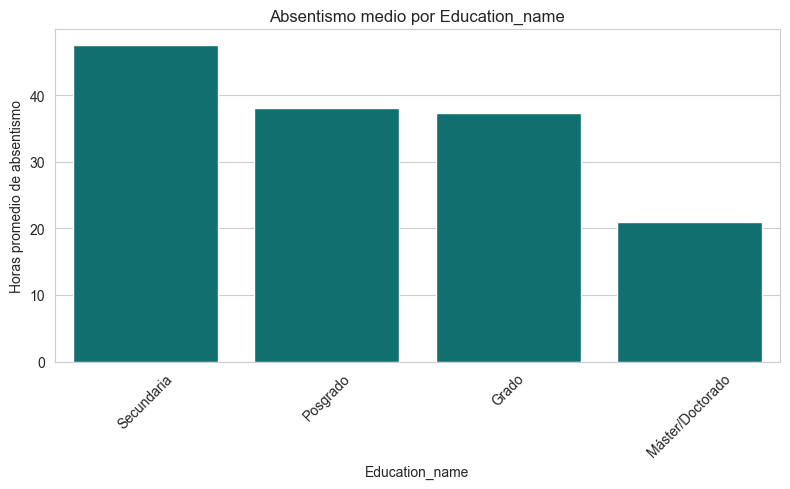

In [6]:
comparar_absentismo(df_empleados, 'Education_name')



Recuento por grupo:
Son
0    59
1    41
2    28
3     5
4     3
Name: count, dtype: int64

Absentismo medio por grupo:
   Son  horas_totales
4    4         104.33
2    2          75.00
1    1          43.00
3    3          43.00
0    0          31.10


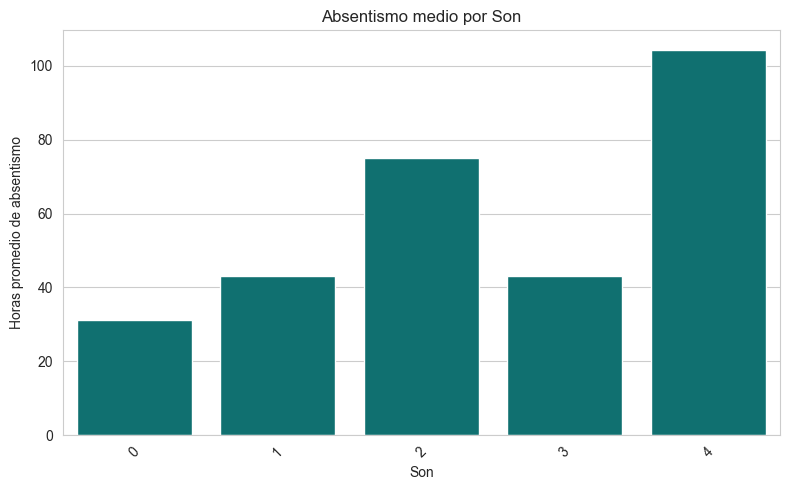

In [7]:
comparar_absentismo(df_empleados, 'Son')



Recuento por grupo:
Social_drinker
1    71
0    65
Name: count, dtype: int64

Absentismo medio por grupo:
   Social_drinker  horas_totales
1               1          53.06
0               0          37.83


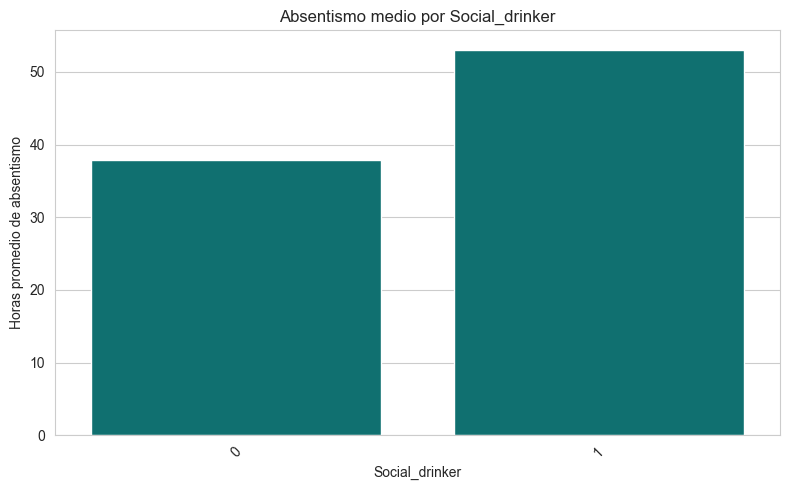

In [8]:
comparar_absentismo(df_empleados, 'Social_drinker')


**Lectura:** las comparaciones por grupos muestran diferencias, pero no bastan para afirmar causalidad. Algunos grupos son pequeños y pueden estar afectados por pocos IDs con muchas horas.


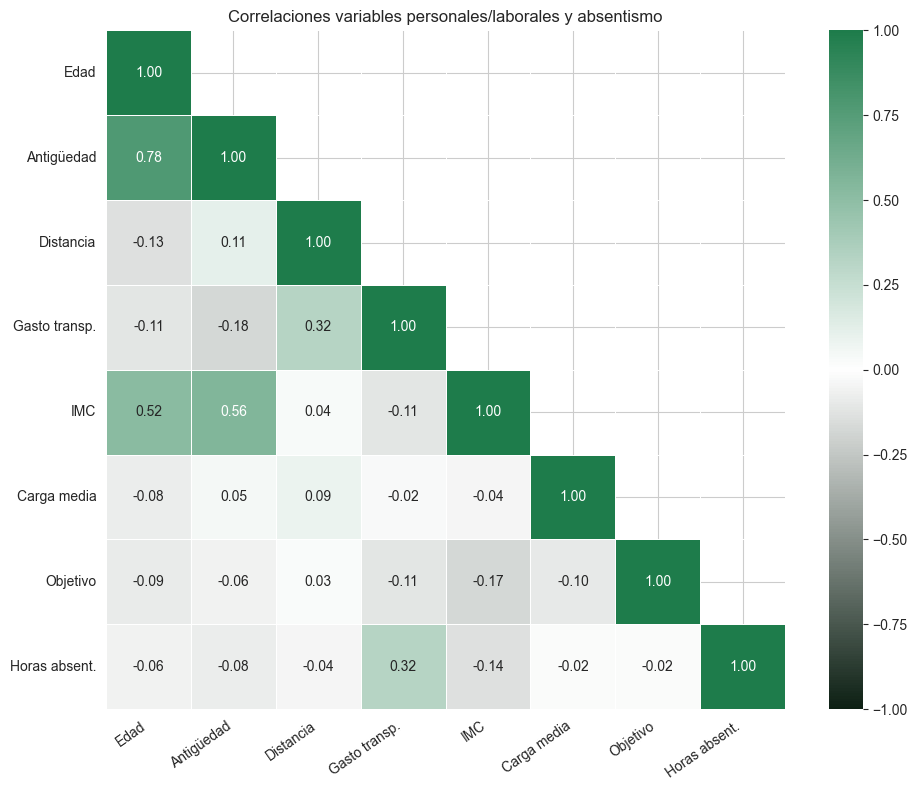

In [9]:
variables_corr = [
    'Age', 'Service_time', 'Distance_Residence_Work', 'Transportation_expense',
    'BMI_calculated', 'Work_load_Average_day', 'Hit_target', 'horas_totales'
]

corr = df_empleados[variables_corr].corr(method='spearman')

labels_es = {
    'Age': 'Edad',
    'Service_time': 'Antigüedad',
    'Distance_Residence_Work': 'Distancia',
    'Transportation_expense': 'Gasto transp.',
    'BMI_calculated': 'IMC',
    'Work_load_Average_day': 'Carga media',
    'Hit_target': 'Objetivo',
    'horas_totales': 'Horas absent.'
}

corr = corr.rename(index=labels_es, columns=labels_es)

cmap_verde = LinearSegmentedColormap.from_list(
    'verde_blanco_verde', ['#0d2014', '#ffffff', '#1e7c4b']
)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(10, 8), facecolor='none')
ax = sns.heatmap(
    corr, annot=True, fmt='.2f', cmap=cmap_verde, center=0,
    mask=mask, square=True, vmin=-1, vmax=1, linewidths=0.5
)
ax.set_facecolor('none')
plt.title('Correlaciones variables personales/laborales y absentismo')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [10]:
correlacion_absentismo = (
    corr[['Horas absent.']]
    .drop(index='Horas absent.')
    .sort_values('Horas absent.', key=abs, ascending=False)
)

correlacion_absentismo


,Horas absent.
Gasto transp.,0.323959
IMC,-0.139297
Antigüedad,-0.083017
Edad,-0.059211
Distancia,-0.043242
Carga media,-0.020630
Objetivo,-0.015963


In [ ]:
correlacion_plot = (
    correlacion_absentismo
    .reset_index()
    .rename(columns={'index': 'variable', 'Horas absent.': 'r_spearman'})
)

plt.figure(figsize=(8, 4.5))
colores = [COLOR_PRINCIPAL if valor >= 0 else COLOR_ALERTA for valor in correlacion_plot['r_spearman']]

sns.barplot(
    data=correlacion_plot,
    y='variable',
    x='r_spearman',
    palette=colores,
    hue='variable',
    legend=False
)

plt.axvline(0, color='black', linewidth=0.8)
plt.xlim(-0.4, 0.4)
plt.title('Spearman: variables personales/laborales vs horas de absentismo')
plt.xlabel('r de Spearman')
plt.ylabel('')
plt.tight_layout()
plt.show()


**Lectura del gráfico Spearman:** las barras muestran la fuerza y dirección de la asociación entre cada variable y las horas acumuladas de absentismo. Todas quedan cerca de cero; por eso se interpretan como señales débiles, no como explicación fuerte.


**Lectura:** las correlaciones con absentismo son débiles. La señal más alta queda lejos de una relación fuerte, por lo que no es riguroso afirmar que una variable personal o laboral explique por sí sola las ausencias.


## 7. Cambio de enfoque: del perfil individual al impacto operativo

Como no aparece una variable individual fuerte, la respuesta debe centrarse en impacto operativo:

- qué motivos acumulan más horas;
- cuándo se concentra la carga;
- si pocas personas/IDs concentran muchas horas;
- qué segmentos agregados conviene investigar sin etiquetar personas.


## 8. Motivos de ausencia: frecuencia vs impacto


In [26]:
absentismo_motivo = df_RRHH.groupby(['Reason_absence', 'Reason_absence_name'], as_index=False).agg(
    registros=('ID', 'size'),
    ids_observados=('ID', 'nunique'),
    horas_totales=('Absenteeism_hours', 'sum'),
    media_horas=('Absenteeism_hours', 'mean'),
    mediana_horas=('Absenteeism_hours', 'median')
).sort_values('horas_totales', ascending=False)

top_motivos = absentismo_motivo
top_motivos


,Reason_absence,Reason_absence_name,registros,ids_observados,horas_totales,media_horas,mediana_horas
12,13.0,Sistema musculoesquelético,68,30,1057,15.544118,8.0
18,19.0,"Lesiones, intoxicaciones y consecuencias externas",49,26,779,15.897959,8.0
21,23.0,Consulta médica,174,49,509,2.925287,2.0
10,11.0,Sistema digestivo,28,15,425,15.178571,8.0
26,28.0,Consulta dental,128,33,370,2.890625,2.0
9,10.0,Sistema respiratorio,33,21,329,9.969697,8.0
20,22.0,Seguimiento de paciente,41,15,317,7.731707,8.0
8,9.0,Sistema circulatorio,7,5,304,43.428571,16.0
11,12.0,Piel y tejido subcutáneo,9,7,299,33.222222,16.0
5,6.0,Sistema nervioso,9,7,291,32.333333,8.0


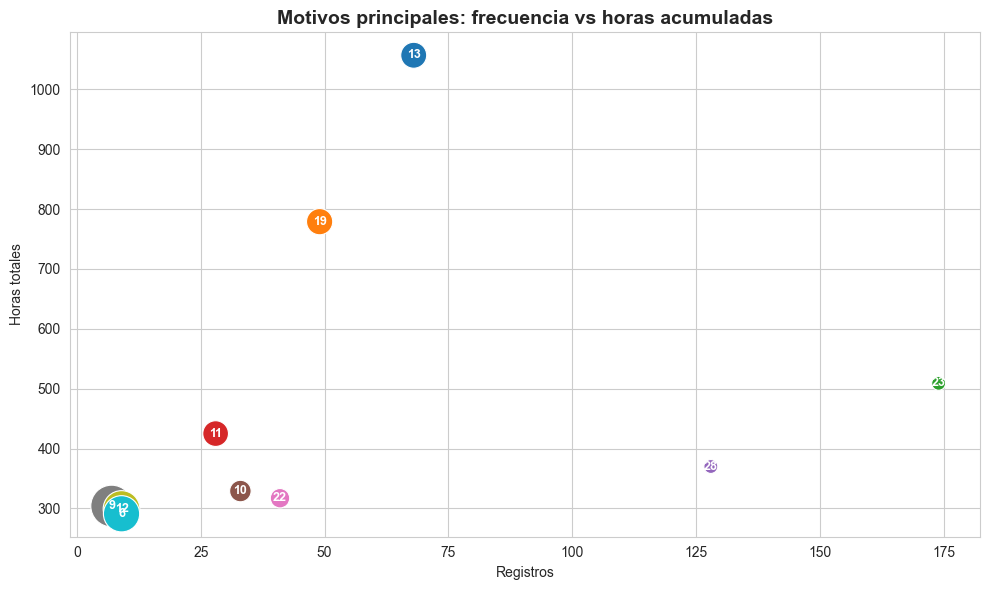

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=top_motivos,
    x='registros',
    y='horas_totales',
    size='media_horas',
    hue='Reason_absence_name',
    sizes=(100, 900),
    legend=False,
    ax=ax
)

for _, fila in top_motivos.iterrows():
    ax.text(
        fila['registros'], fila['horas_totales'], int(fila['Reason_absence']),
        ha='center', va='center', color='white', fontweight='bold', fontsize=9
    )

ax.set_title('Motivos principales: frecuencia vs horas acumuladas', fontsize=14, fontweight='bold')
ax.set_xlabel('Registros')
ax.set_ylabel('Horas totales')
plt.tight_layout()
plt.show()


**Lectura:** este gráfico separa recurrencia e impacto. Los motivos con más horas acumuladas orientan mejor las políticas de prevención que una lectura basada solo en frecuencia.


## 9. Días y meses con mayor carga


In [13]:
absentismo_mes = df_RRHH.groupby(['Month_absence', 'Month_absence_name'], as_index=False).agg(
    registros=('ID', 'size'),
    horas_totales=('Absenteeism_hours', 'sum')
).sort_values('Month_absence')

absentismo_dia = df_RRHH.groupby(['Day_week', 'Day_week_name'], as_index=False).agg(
    registros=('ID', 'size'),
    horas_totales=('Absenteeism_hours', 'sum')
).sort_values('Day_week')


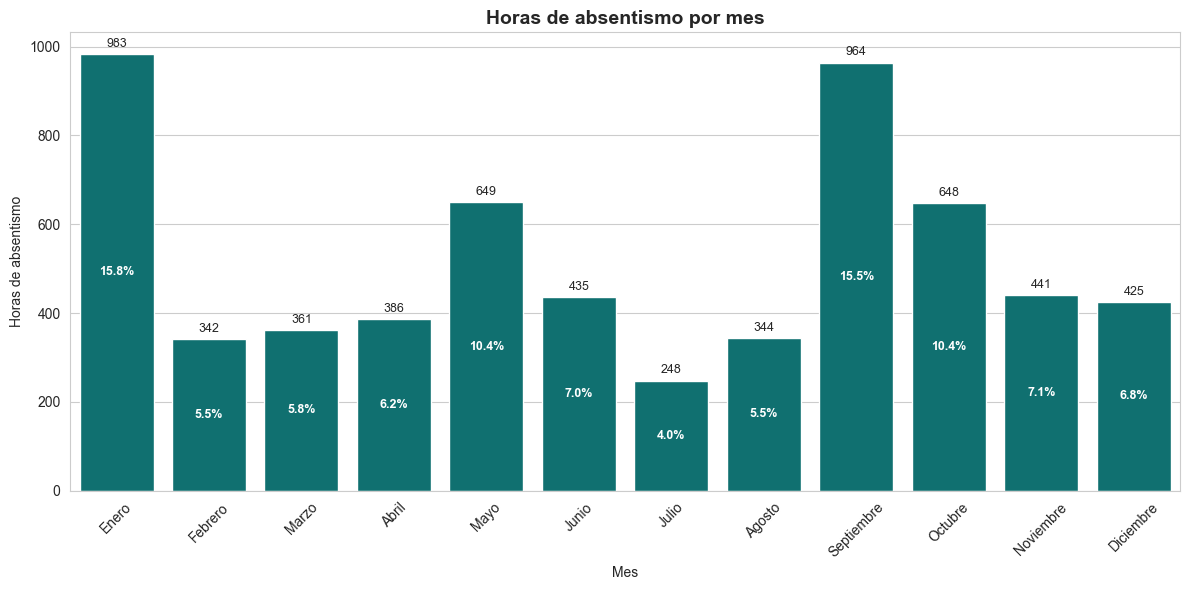

In [14]:
data = absentismo_mes.copy()
total_horas = data['horas_totales'].sum()
data['pct_horas'] = data['horas_totales'] / total_horas * 100

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=data, x='Month_absence_name', y='horas_totales', color=COLOR_PRINCIPAL, ax=ax)
ax.set_title('Horas de absentismo por mes', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Horas de absentismo')
ax.tick_params(axis='x', rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9)

for i, fila in data.reset_index(drop=True).iterrows():
    ax.text(i, fila['horas_totales'] / 2, f"{fila['pct_horas']:.1f}%", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


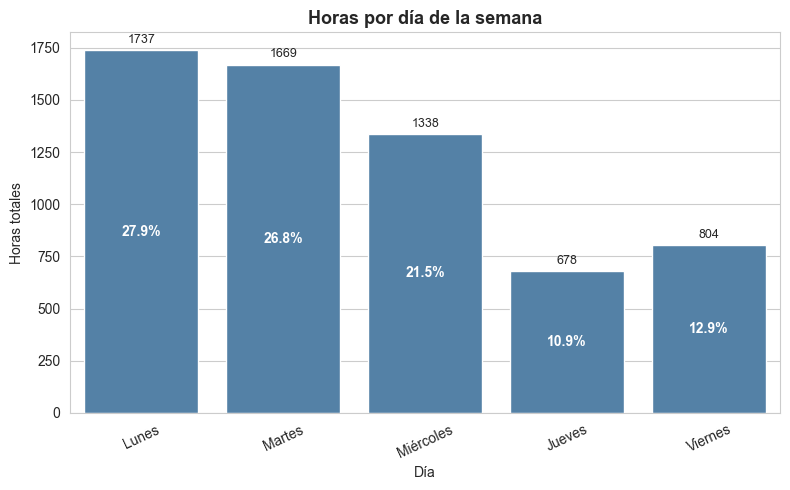

In [15]:
total_horas = df_RRHH['Absenteeism_hours'].sum()
absentismo_dia['pct_horas'] = absentismo_dia['horas_totales'] / total_horas * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=absentismo_dia, x='Day_week_name', y='horas_totales', color=COLOR_SECUNDARIO, ax=ax)
ax.set_title('Horas por día de la semana', fontsize=13, fontweight='bold')
ax.set_xlabel('Día')
ax.set_ylabel('Horas totales')
ax.tick_params(axis='x', rotation=25)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9)

for i, fila in absentismo_dia.reset_index(drop=True).iterrows():
    ax.text(i, fila['horas_totales'] / 2, f"{fila['pct_horas']:.1f}%", ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()


**Lectura:** meses y días con mayor carga sirven para planificar cobertura, turnos o sustituciones. La limitación es que el dataset no incluye año ni semana, por lo que no permite una evolución temporal precisa.


## 10. Concentración por ID


In [16]:
absentismo_id = df_RRHH.groupby('ID', as_index=False).agg(
    registros=('ID', 'size'),
    horas_totales=('Absenteeism_hours', 'sum')
).sort_values('horas_totales', ascending=False)

top_ids = absentismo_id.head(10)

top_10_share = top_ids['horas_totales'].sum() / df_RRHH['Absenteeism_hours'].sum() * 100
top_5_share = absentismo_id.head(5)['horas_totales'].sum() / df_RRHH['Absenteeism_hours'].sum() * 100

print('Top 10 IDs concentran:', round(top_10_share, 1), '% de las horas')
print('Top 5 IDs concentran:', round(top_5_share, 1), '% de las horas')

top_ids


Top 10 IDs concentran: 65.4 % de las horas
Top 5 IDs concentran: 39.8 % de las horas


,ID,registros,horas_totales
13,14,30,596
8,9,10,494
2,3,113,482
27,28,77,459
10,11,40,450
35,36,35,431
33,34,55,344
19,20,42,306
23,24,30,254
21,22,46,253


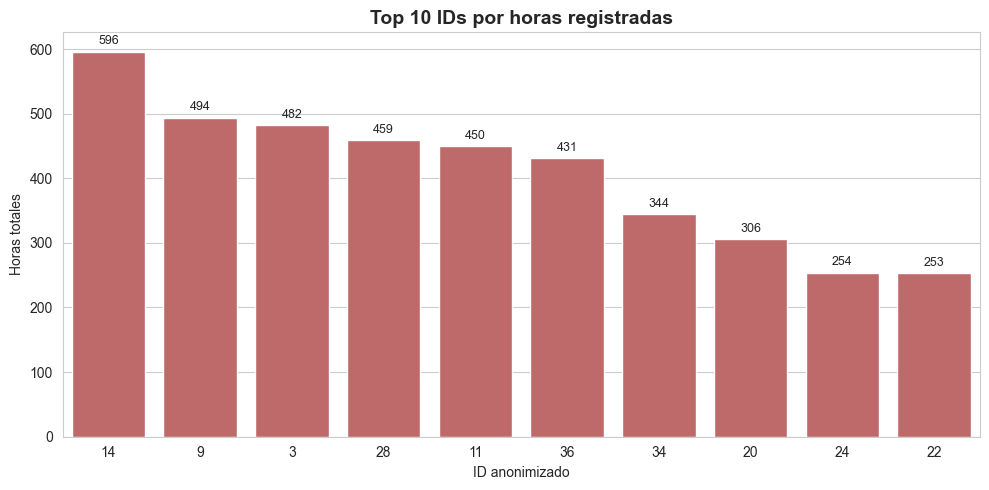

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top_ids, x='ID', y='horas_totales', color=COLOR_ALERTA, order=top_ids['ID'], ax=ax)
ax.set_title('Top 10 IDs por horas registradas', fontsize=14, fontweight='bold')
ax.set_xlabel('ID anonimizado')
ax.set_ylabel('Horas totales')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()


**Lectura:** la concentración por ID no debe usarse para señalar personas. Sirve para detectar si el impacto requiere seguimiento confidencial con más contexto: puesto, centro, turno, contrato y situación laboral.


## 10.1. Pareto de horas por ID

El Pareto ayuda a comprobar si una parte pequeña de IDs concentra una parte grande de las horas de absentismo.

No se usa para señalar personas. Se usa para decidir si RRHH necesita una vía de seguimiento confidencial con más contexto.


In [18]:
pareto_id = absentismo_id.copy()
pareto_id['pct_horas'] = pareto_id['horas_totales'] / pareto_id['horas_totales'].sum() * 100
pareto_id['pct_acumulado'] = pareto_id['pct_horas'].cumsum()
pareto_id['orden'] = range(1, len(pareto_id) + 1)

ids_hasta_80 = pareto_id[pareto_id['pct_acumulado'] <= 80].shape[0] + 1
pct_top_10 = pareto_id.head(10)['horas_totales'].sum() / pareto_id['horas_totales'].sum() * 100

print('IDs necesarios para alcanzar aproximadamente el 80% de las horas:', ids_hasta_80)
print('Top 10 IDs concentran:', round(pct_top_10, 1), '% de las horas')

pareto_id.head(20)


IDs necesarios para alcanzar aproximadamente el 80% de las horas: 16
Top 10 IDs concentran: 65.4 % de las horas


,ID,registros,horas_totales,pct_horas,pct_acumulado,orden
13,14,30,596,9.572759,9.572759,1
8,9,10,494,7.934468,17.507228,2
2,3,113,482,7.741728,25.248956,3
27,28,77,459,7.372310,32.621266,4
10,11,40,450,7.227755,39.849020,5
35,36,35,431,6.922583,46.771603,6
33,34,55,344,5.525217,52.296820,7
19,20,42,306,4.914873,57.211693,8
23,24,30,254,4.079666,61.291359,9
21,22,46,253,4.063604,65.354963,10


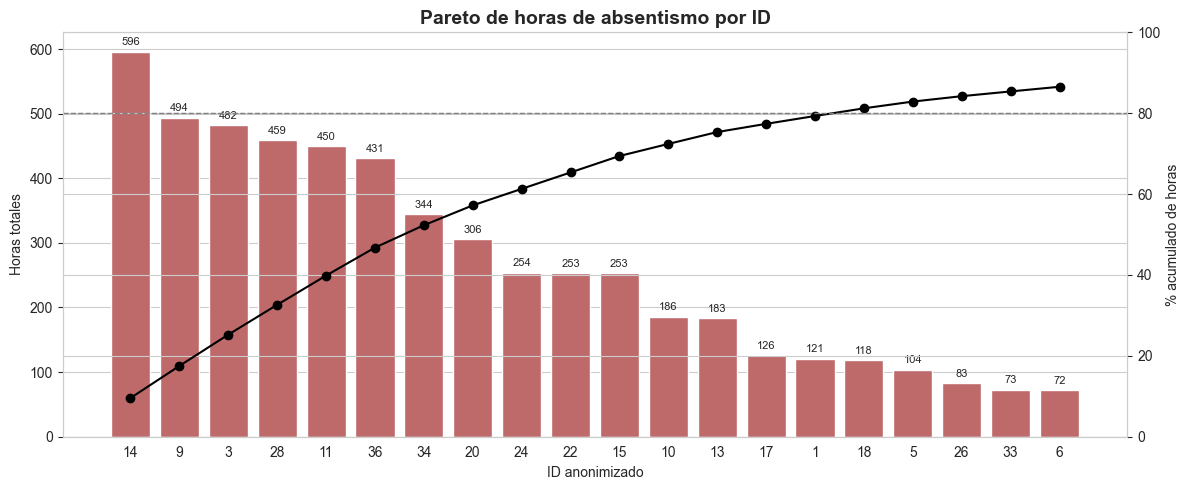

In [19]:
pareto_top = pareto_id.head(20).copy()

fig, ax1 = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=pareto_top,
    x='orden',
    y='horas_totales',
    color=COLOR_ALERTA,
    ax=ax1
)

ax1.set_title('Pareto de horas de absentismo por ID', fontsize=14, fontweight='bold')
ax1.set_xlabel('ID anonimizado')
ax1.set_ylabel('Horas totales')
ax1.set_xticks(range(len(pareto_top)))
ax1.set_xticklabels(pareto_top['ID'].astype(str), rotation=0)

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.0f', padding=3, fontsize=8)

ax2 = ax1.twinx()
ax2.plot(
    range(len(pareto_top)),
    pareto_top['pct_acumulado'],
    color='black',
    marker='o'
)
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel('% acumulado de horas')
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()


**Lectura:** el Pareto confirma una concentración importante: los **10 IDs con más horas acumulan cerca del 65,4%** del total, y hacen falta aproximadamente **16 IDs** para alcanzar el 80% de las horas.

Esto refuerza la idea de impacto operativo concentrado. La política no debe ser exponer IDs, sino abrir una revisión confidencial con datos de puesto, centro, turno, contrato y causa de ausencia.


## 11. Segmentos agregados para investigar

Como alternativa a una lectura individual, comparamos segmentos con el porcentaje de IDs en absentismo elevado.


In [20]:
df_empleados['tramo_distancia'] = pd.cut(
    df_empleados['Distance_Residence_Work'],
    bins=[0, 10, 20, 30, 100],
    labels=['<=10 km', '11-20 km', '21-30 km', '>30 km']
)

df_empleados['tramo_antiguedad'] = pd.cut(
    df_empleados['Service_time'],
    bins=[0, 5, 10, 15, 40],
    labels=['<=5 años', '6-10 años', '11-15 años', '>15 años']
)

def comparar_segmentos(df, variable):
    tabla = df.groupby(variable, observed=False).agg(
        ids_observados=('ID', 'size'),
        horas_totales=('horas_totales', 'sum'),
        media_horas=('horas_totales', 'mean'),
        mediana_horas=('horas_totales', 'median'),
        ids_absentismo_elevado=('absentismo_elevado', 'sum')
    ).reset_index()

    tabla['pct_absentismo_elevado'] = (
        tabla['ids_absentismo_elevado'] / tabla['ids_observados'] * 100
    ).round(1)

    return tabla.sort_values('pct_absentismo_elevado', ascending=False)


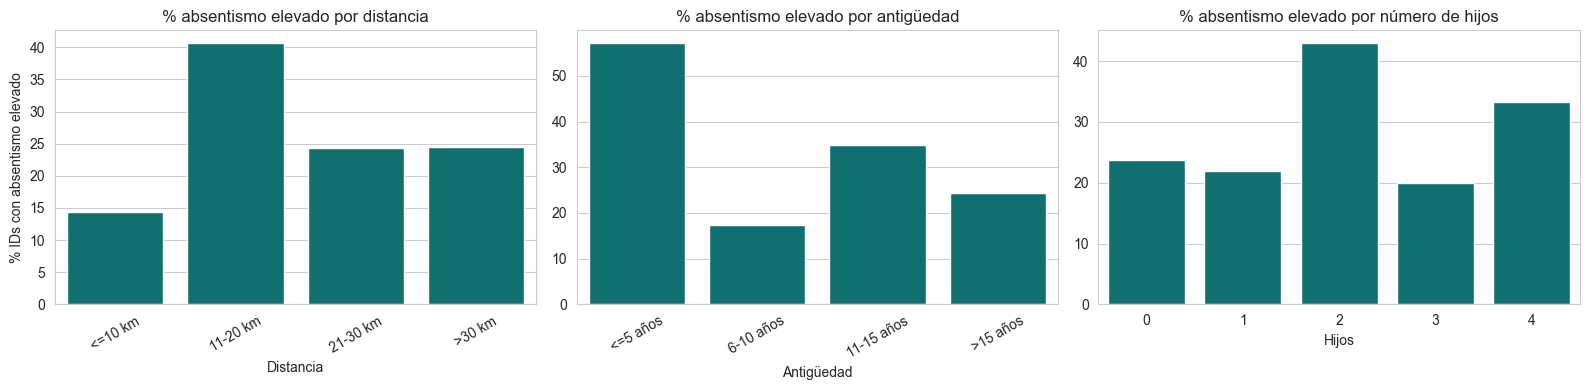

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=comparar_segmentos(df_empleados, 'tramo_distancia'), x='tramo_distancia', y='pct_absentismo_elevado', ax=axes[0], color=COLOR_PRINCIPAL)
axes[0].set_title('% absentismo elevado por distancia')
axes[0].set_xlabel('Distancia')
axes[0].set_ylabel('% IDs con absentismo elevado')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=comparar_segmentos(df_empleados, 'tramo_antiguedad'), x='tramo_antiguedad', y='pct_absentismo_elevado', ax=axes[1], color=COLOR_PRINCIPAL)
axes[1].set_title('% absentismo elevado por antigüedad')
axes[1].set_xlabel('Antigüedad')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)

sns.barplot(data=comparar_segmentos(df_empleados, 'Son'), x='Son', y='pct_absentismo_elevado', ax=axes[2], color=COLOR_PRINCIPAL)
axes[2].set_title('% absentismo elevado por número de hijos')
axes[2].set_xlabel('Hijos')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()


**Lectura:** estos segmentos no son perfiles de riesgo. Son señales para investigar conciliación, movilidad, etapa laboral y organización del trabajo con más datos.


## 12. Respuesta final a la pregunta de negocio

No aparece una variable personal o laboral que explique de forma fuerte el absentismo elevado. Esto coincide con el análisis de perfil/desempeño: las relaciones lineales con absentismo son débiles.

Por tanto, la respuesta no debe centrarse en señalar perfiles, sino en actuar sobre el impacto operativo:

- motivos que acumulan más horas;
- días y meses de mayor carga;
- concentración de horas en pocos IDs;
- segmentos agregados donde conviene investigar políticas internas.


## 13. Propuestas de políticas internas


In [22]:
tabla_politicas = pd.DataFrame({
    'hallazgo': [
        'Motivos musculoesqueléticos concentran muchas horas',
        'Algunos días y meses concentran más carga registrada',
        'Pocos IDs acumulan una parte alta de las horas',
        'Hijos, distancia o transporte muestran señales exploratorias',
        'Correlaciones personales/laborales débiles'
    ],
    'interpretacion': [
        'El impacto parece más relacionado con salud laboral y condiciones físicas que con un perfil individual claro.',
        'El absentismo tiene impacto operativo desigual en el calendario disponible.',
        'La concentración requiere análisis confidencial y contextual, no exposición pública de personas.',
        'Pueden orientar preguntas sobre conciliación, movilidad u horarios, sin asumir causalidad.',
        'No conviene construir políticas basadas en perfiles individuales o modelos lineales simples.'
    ],
    'posible_politica_interna': [
        'Prevención ergonómica, revisión de cargas físicas y seguimiento de salud laboral.',
        'Planificación de cobertura, turnos y sustituciones en momentos de mayor presión.',
        'Seguimiento confidencial con información de puesto, centro, turno y contrato.',
        'Revisar medidas de conciliación, flexibilidad, transporte u organización horaria.',
        'Usar segmentos agregados e impacto operativo como base para priorizar decisiones.'
    ]
})

tabla_politicas


,hallazgo,interpretacion,posible_politica_interna
0,Motivos musculoesqueléticos concentran muchas ...,El impacto parece más relacionado con salud la...,"Prevención ergonómica, revisión de cargas físi..."
1,Algunos días y meses concentran más carga regi...,El absentismo tiene impacto operativo desigual...,"Planificación de cobertura, turnos y sustituci..."
2,Pocos IDs acumulan una parte alta de las horas,La concentración requiere análisis confidencia...,Seguimiento confidencial con información de pu...
3,"Hijos, distancia o transporte muestran señales...","Pueden orientar preguntas sobre conciliación, ...","Revisar medidas de conciliación, flexibilidad,..."
4,Correlaciones personales/laborales débiles,No conviene construir políticas basadas en per...,Usar segmentos agregados e impacto operativo c...


### Cierre

La conclusión principal es que el absentismo no se resuelve señalando perfiles individuales. La intervención más útil para RRHH debe combinar prevención, planificación operativa y análisis agregado de segmentos a investigar.
